In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()
x_train=x_train.reshape(-1,784)/255.0
x_test=x_test.reshape(-1,784)/255.0
def create_model(lr):
    m=Sequential([Dense(128,activation='relu',input_shape=(784,)),
                  Dense(64,activation='relu'),
                  Dense(10,activation='softmax')])
    m.compile(optimizer=Adam(learning_rate=lr),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


   Learning Rate  Accuracy
0          0.100    0.6019
1          0.010    0.8641
2          0.001    0.8682


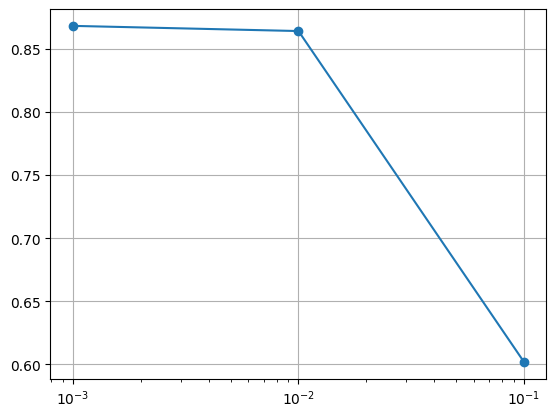

In [ ]:
learning_rates=[0.1,0.01,0.001]
results=[]
for lr in learning_rates:
    model=create_model(lr)
    model.fit(x_train,y_train,epochs=5,batch_size=128,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    results.append([lr,acc])
df=pd.DataFrame(results,columns=['Learning Rate','Accuracy'])
print(df)
plt.plot(df['Learning Rate'],df['Accuracy'],marker='o')
plt.xscale('log'); plt.grid(); plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Accuracy
0       5    0.8689
1      10    0.8799
2      20    0.8795


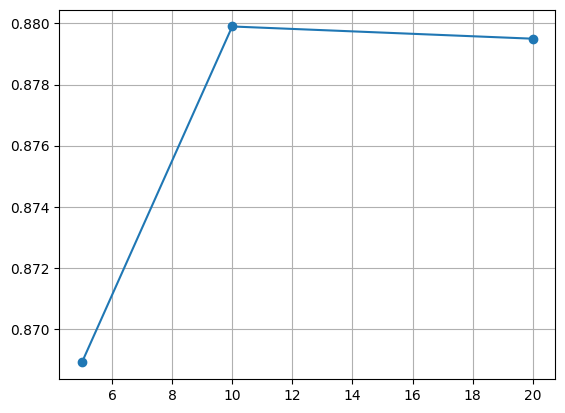

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7957 - loss: 0.5832 - val_accuracy: 0.8444 - val_loss: 0.4380
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8558 - loss: 0.4080 - val_accuracy: 0.8578 - val_loss: 0.3987
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8689 - loss: 0.3682 - val_accuracy: 0.8698 - val_loss: 0.3654
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8773 - loss: 0.3399 - val_accuracy: 0.8777 - val_loss: 0.3517
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8840 - loss: 0.3185 - val_accuracy: 0.8809 - val_loss: 0.3312
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8897 - loss: 0.3039 - val_accuracy: 0.8657 - val_loss: 0.3663
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8953 - loss: 0.2858 - val_accuracy: 0.8782 - val_loss: 0.3401
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8989 - loss: 0.2761 - val_accuracy: 0.

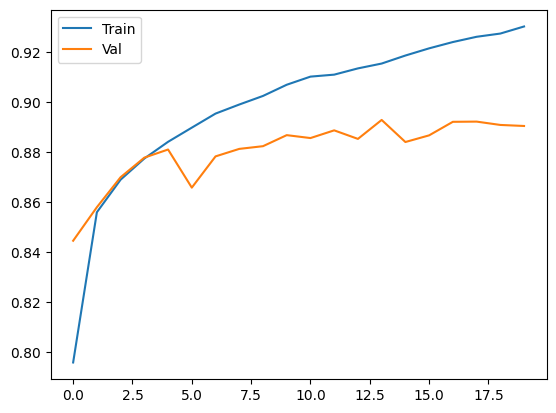

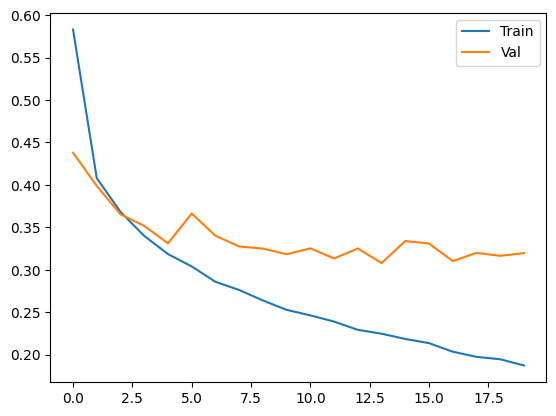

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8846 - loss: 0.3459
[0.34594491124153137, 0.8845999836921692]


In [ ]:
epochs_list=[5,10,20]
res=[]
for ep in epochs_list:
    model=create_model(0.001)
    h=model.fit(x_train,y_train,validation_split=0.2,epochs=ep,batch_size=128,verbose=0)
    loss,acc=model.evaluate(x_test,y_test,verbose=0)
    res.append([ep,acc])
edf=pd.DataFrame(res,columns=['Epochs','Accuracy'])
print(edf)
plt.plot(edf['Epochs'],edf['Accuracy'],marker='o')
plt.grid(); plt.show()

model=create_model(0.001)
history=model.fit(x_train,y_train,validation_split=0.2,epochs=20,batch_size=128)
plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy']); plt.legend(['Train','Val']); plt.show()
plt.plot(history.history['loss']); plt.plot(history.history['val_loss']); plt.legend(['Train','Val']); plt.show()
print(model.evaluate(x_test,y_test))


### Detailed Model Evaluation: Confusion Matrix and Classification Report

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


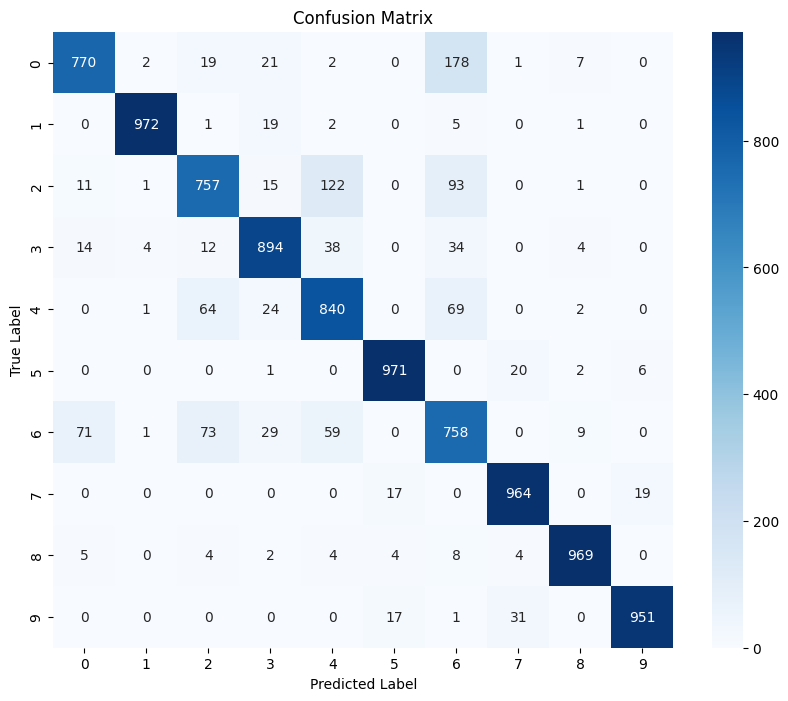


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.76      0.78      1000
           3       0.89      0.89      0.89      1000
           4       0.79      0.84      0.81      1000
           5       0.96      0.97      0.97      1000
           6       0.66      0.76      0.71      1000
           7       0.95      0.96      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.89     10000
weighted avg       0.89      0.88      0.89     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

### Visualizing Misclassified Images

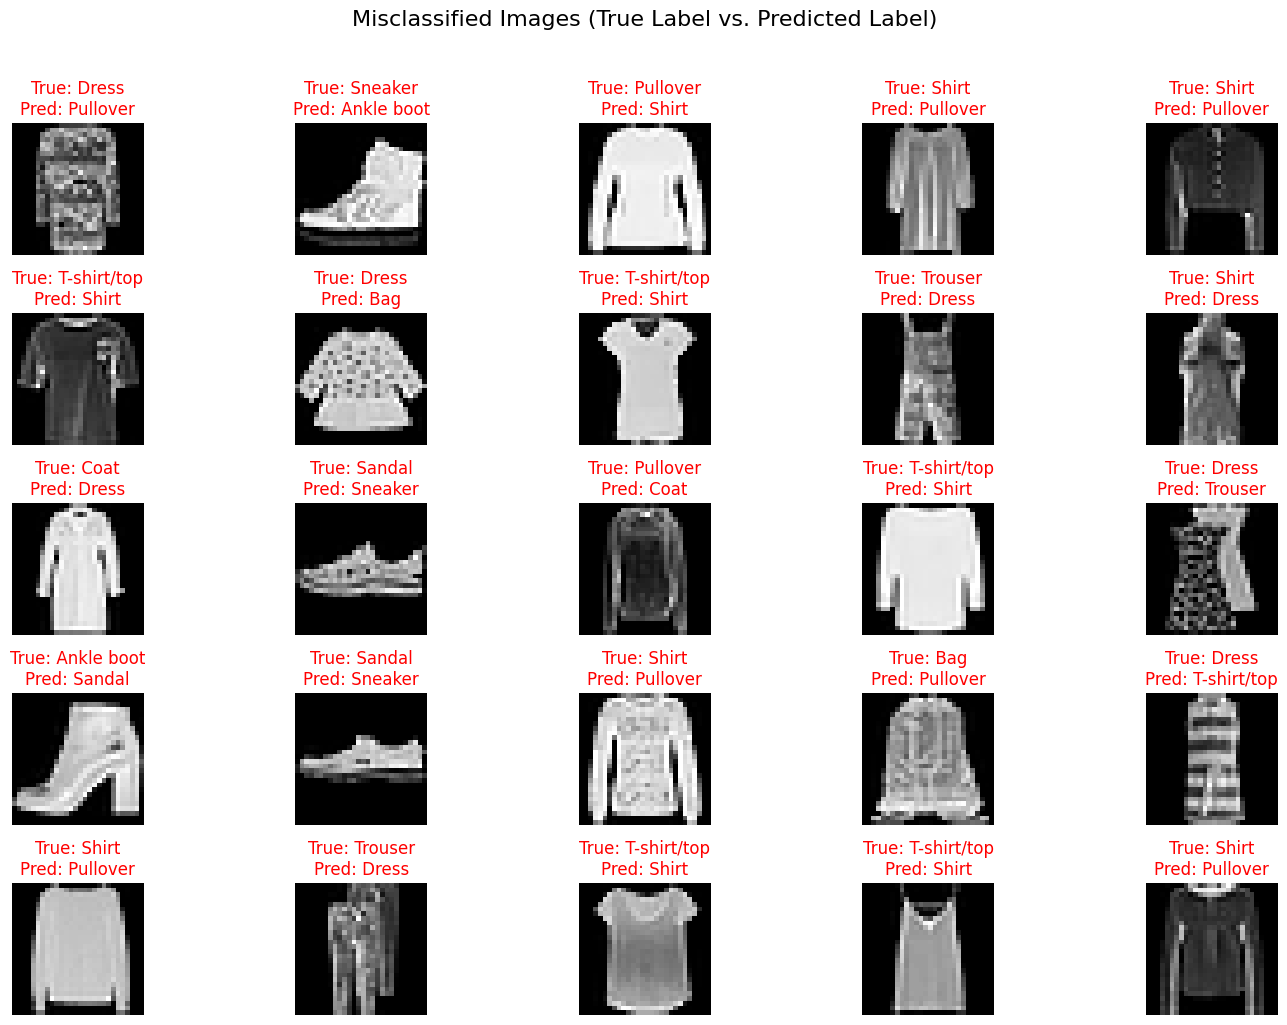

In [ ]:
# Find misclassified indices
misclassified_idx = np.where(y_pred != y_test)[0]

# Get class names for better readability (Fashion MNIST has 10 classes)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot a sample of misclassified images
plt.figure(figsize=(15, 10))
for i, idx in enumerate(np.random.choice(misclassified_idx, size=25, replace=False)):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}",
              color='red' if y_pred[idx] != y_test[idx] else 'black')
    plt.axis('off')
plt.suptitle('Misclassified Images (True Label vs. Predicted Label)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()